In [1]:
import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import sys

sys.path.insert(0, "../..")

In [2]:
import chex
import dill
import jax
import jax.numpy as jnp
import jax.random as jrandom
import json
import math
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import scipy
import torch
import seaborn as sns

from flax import nnx
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from typing import Any, NamedTuple
from typing_extensions import Protocol, runtime_checkable

from src.constants import *
from src.dataset import get_iter
from src.datasets.sum import Addition
from src.decoding import make_autoregressive
from src.rollout import rollout
from src.utils import parse_dict
from src.verifier import make_compute_returns

In [3]:
plt.style.use("seaborn-v0_8-colorblind")

In [ ]:
base_path = "/home/bryanpu1/projects/parallel_vs_serial/scaling_jax/results"
algo_name = "addition-max_int_64-no_eos-reset_immediately"

group_name = "algo_compare"
run_names = {
    "Traj. Improvement": "ppo-scratch_1M-traj_improvement_fixed-discounting-0_cot_tokens-8x8-01-25-26_07_52_41-cfc6a873-9c41-4c29-9dac-d83eb011a4f9",
    "Vanilla PPO": "ppo_kl-scratch_1M-0_cot_tokens-8x8-01-23-26_11_05_40-93cc131e-8f27-4175-88b1-51de541e4d0b",
    "Meta RL": "ppo-scratch_1M-meta_rl-0_cot_tokens-8x8-01-23-26_11_08_43-9a5c8346-6c12-4081-9a21-24acf4c0133d",
    "Off-policy Context PPO": "opc_ppo-scratch_1M-0_cot_tokens-8x8-01-26-26_07_00_51-eaee1709-185a-4366-938f-752d2aefd1ea",
    "Off-policy Context Traj. Improvement": "opc_ppo-scratch_1M-traj_improvement-0_cot_tokens-8x8-01-26-26_06_57_54-72a716da-5119-4bad-92d3-d498cbe06d27",
    "Progress PPO": "ppo-scratch_1M-progress_rl-0_cot_tokens-8x8-01-25-26_07_51_57-6bd6ac0b-f1ec-4a21-a1e2-3c973f0a4b7b",
}


# group_name = "opc_traj_improve_ablation"
# run_names = {
#     "Default": "opc_ppo-scratch_1M-traj_improvement-0_cot_tokens-8x8-01-26-26_06_57_54-72a716da-5119-4bad-92d3-d498cbe06d27",
#     "Only save multiple attempts": "opc_ppo-scratch_1M-save_when_multiple_attempts-traj_improvement-0_cot_tokens-8x8-01-27-26_12_59_40-73ff08af-b185-42ca-b43c-d78b3a750567",
#     "Clip higher + save multiple attempts": "opc_ppo-scratch_1M-clip_high-save_when_multiple_attempts-traj_improvement-0_cot_tokens-8x8-01-27-26_15_12_47-b69126b6-368a-4996-bb6f-9426b87306c1",
# }

learner_path = os.path.join(base_path, algo_name, list(run_names.values())[0])

eval_seed = 42
# num_evals = 1
num_evals = 128
max_bits = 12
batch_size_per_block = 50
batch_size = 500
checkpoint_i = 10
max_response_length = 200
hide_question = False
max_decode_len = max_response_length if hide_question else 2 * max_bits + 1 + max_response_length

config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))
half_precision = config_dict["half_precision"]
dtype = jnp.bfloat16 if half_precision else jnp.float32

# Get dataset
max_int = int(2 ** max_bits)
config = parse_dict(config_dict)
dataset_kwargs = config.dataset_kwargs

save_name = "attempt_diversity_results-{}-checkpoint_{}-max_response_length_{}{}{}.dill".format(
    group_name,
    checkpoint_i * config.logging_config.checkpoint_interval if checkpoint_i >= 0 else "last",
    max_response_length,
    "-hide_question" if hide_question else "",
    "-deterministic" if num_evals == 1 else "",
)

## Rollout

In [5]:
if config.dataset_name == "curriculum":
    train_num_bits = int(np.ceil(np.log2(dataset_kwargs.datasets[-1]["dataset_kwargs"]["max_int"])))
    train_val_ratio = dataset_kwargs.datasets[-1]["dataset_kwargs"]["train_val_ratio"]
    predict_eos = dataset_kwargs.datasets[-1]["dataset_kwargs"]["predict_eos"]
    num_cot_tokens = dataset_kwargs.datasets[-1]["dataset_kwargs"]["num_cot_tokens"]
    right_to_left = dataset_kwargs.datasets[-1]["dataset_kwargs"]["right_to_left"]
    correctness_aware = dataset_kwargs.datasets[-1]["dataset_kwargs"]["correctness_aware"]
    carry_registers = dataset_kwargs.datasets[-1]["dataset_kwargs"]["carry_registers"]
    train_max_decode_len = dataset_kwargs.datasets[-1]["dataset_kwargs"]["context_len"]
else:
    train_num_bits = int(np.ceil(np.log2(dataset_kwargs.max_int)))
    train_val_ratio = dataset_kwargs.train_val_ratio
    predict_eos = dataset_kwargs.predict_eos
    num_cot_tokens = dataset_kwargs.num_cot_tokens
    right_to_left = dataset_kwargs.right_to_left
    correctness_aware = dataset_kwargs.correctness_aware
    carry_registers = getattr(dataset_kwargs, "carry_registers", False)
    train_max_decode_len = dataset_kwargs.context_len

dataset = Addition(
    context_len=max_decode_len,
    max_int=max_int,
    train=True,
    seed=eval_seed,
    sequence_type="question_only",
    train_val_ratio=1.0,
    right_to_left=right_to_left,
    num_repeats=1,
    shuffle=True,
    exact=True,
    predict_eos=predict_eos,
    num_cot_tokens=num_cot_tokens,
    p_curriculum=0.0,
    p_inject_noop=0.0,
    max_noops=0,
    noop_as_pad=False,
    reverse_curriculum=False,
    correctness_aware=correctness_aware,
    carry_registers=carry_registers,
)

out_dim = int(dataset.output_space.n)
data_loader = DataLoader(
    dataset,
    batch_size=batch_size_per_block,
    num_workers=0,
)
data_iter = get_iter(data_loader, None, dtype)

EOS TOKEN: 6
TOKEN MAP: {0: 0, 1: 1, 2: 2, 3: 3, 6: 6, 4: 4, 5: 5}


In [6]:
for exp_name, run_name in run_names.items():
    learner_path = os.path.join(base_path, algo_name, run_name)
    print("{} {}".format(exp_name, sorted(os.listdir(os.path.join(learner_path, "models")))))

Traj. Improvement ['0000000.dill', '0050000.dill', '0100000.dill', '0150000.dill', '0200000.dill', '0250000.dill', '0300000.dill', '0350000.dill', '0400000.dill', '0450000.dill', '0500000.dill', '0550000.dill', '0600000.dill', '0650000.dill', '0700000.dill', '0750000.dill', '0800000.dill', '0850000.dill', '0900000.dill', '0950000.dill', '1000000.dill']
Vanilla PPO ['0000000.dill', '0050000.dill', '0100000.dill', '0150000.dill', '0200000.dill', '0250000.dill', '0300000.dill', '0350000.dill', '0400000.dill', '0450000.dill', '0500000.dill', '0550000.dill', '0600000.dill', '0650000.dill', '0700000.dill', '0750000.dill', '0800000.dill', '0850000.dill', '0900000.dill', '0950000.dill', '1000000.dill']
Meta RL ['0000000.dill', '0050000.dill', '0100000.dill', '0150000.dill', '0200000.dill', '0250000.dill', '0300000.dill', '0350000.dill', '0400000.dill', '0450000.dill', '0500000.dill', '0550000.dill', '0600000.dill', '0650000.dill', '0700000.dill', '0750000.dill', '0800000.dill', '0850000.dill',

In [7]:
def compute_expected_trials(batch_i, batch):
    action_ordering = jax.vmap(lambda rng: jrandom.permutation(
        rng,
        out_dim,
    ))(
        jrandom.split(
            jrandom.fold_in(jrandom.PRNGKey(eval_seed), 0),
            batch_size_per_block * num_evals * max_response_length,
        )
    )
    action_ordering = action_ordering.reshape((batch_size_per_block * num_evals, max_response_length, out_dim))
    action_ordering = jnp.transpose(action_ordering, (2, 1, 0))

    @jax.jit
    def _match_bits(bits, curr_action):
        return bits == curr_action

    match_bits = jax.vmap(_match_bits, in_axes=[None, 0])

    def _get_num_tries(prev_count, curr_bit):
        match_bit_mask = match_bits(
            jnp.array(batch["target"])[:, curr_bit],
            action_ordering[:, curr_bit],
        )

        pred_mask = jnp.array(batch["solution_len"]) >= (curr_bit + 1)

        match_bit_mask *= jnp.arange(1, 1 + out_dim)[:, None]
        match_bit_mask = pred_mask * jnp.sum(match_bit_mask, axis=0)
        retry_length = match_bit_mask * (curr_bit + 1)
        curr_count = prev_count + jnp.concatenate(
            (match_bit_mask[:, None], retry_length[:, None]),
            axis=-1,
        )
        return curr_count, curr_count

    num_retries, counts = jax.lax.scan(
        _get_num_tries,
        jnp.zeros((len(batch["target"]), 2), dtype=int),
        jnp.arange(max_response_length),
    )
    return num_retries.T

In [8]:
if os.path.isfile(save_name):
    results = dill.load(open(save_name, "rb"))
else:
    results = dict()

    for batch_i in range(batch_size // batch_size_per_block):
        batch = next(data_iter)

        if hide_question:
            batch["sequence"][:] = dataset.reset_token_id
            batch["mask"][:] = 1
            batch["question_len"][:] = 0
            print(batch.keys())

        batch = {
            k: np.repeat(v, num_evals, axis=0)
            for k, v in batch.items()
        }

        curr_result = compute_expected_trials(batch_i, batch)
        curr_result = jnp.vstack((
            np.array(curr_result[1] <= max_response_length),
            np.array(curr_result[1]),
            np.array(curr_result[0]),
        ), dtype=int)
        if batch_i == 0:
            results["BFS"] = curr_result
        else:
            results["BFS"] = jnp.hstack((results["BFS"], curr_result))

        for exp_name, run_name in tqdm(run_names.items()):
            learner_path = os.path.join(base_path, algo_name, run_name)
            config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))

            # Load model
            last_step = sorted(os.listdir(os.path.join(learner_path, "models")))[checkpoint_i]
            print(exp_name, last_step)
            train_state = dill.load(
                open(os.path.join(learner_path, "models", last_step), "rb")
            )

            model = nnx.merge(
                train_state.graphdef,
                train_state.params,
                train_state.rest,
            )

            rng = jax.random.PRNGKey(eval_seed)
            rng, rollout_rng = jax.random.split(rng)

            # Sample next batch and evaluate
            _, init_cache = make_autoregressive(
                model,
                max_decode_len=max_decode_len,
                batch_size=batch_size_per_block * num_evals,
                embed_dim=config_dict["model_config"]["model_kwargs"]["embed_dim"],
                dtype=dtype,
                eval_mode=True,
            )
            cache = init_cache()
            graphdef, _, rest = nnx.split(model, nnx.Cache, ...)

            rollout_res = rollout(
                graphdef,
                cache,
                rest,
                rollout_rng,
                batch,
                eos_token=dataset.eos_token_id,
                deterministic=int(num_evals == 1),
                correct_aware_shift=dataset.correctness_aware_tokens_offset,
                max_token_id_to_shift=dataset.max_token_id_to_shift,
            )

            num_resets = np.sum((rollout_res.observations * rollout_res.pred_mask) == dataset.reset_token_id, axis=-1)

            curr_result = jnp.vstack((
                np.array(rollout_res.success),
                np.array(rollout_res.response_length),
                np.array(num_resets),
            ), dtype=int)
            if batch_i == 0:
                results[exp_name] = curr_result
            else:
                results[exp_name] = jnp.hstack((results[exp_name], curr_result))

    dill.dump(
        results,
        open(save_name, "wb"),
    )

  0%|          | 0/6 [00:00<?, ?it/s]

Traj. Improvement 0500000.dill
Vanilla PPO 0500000.dill
Meta RL 0500000.dill
Off-policy Context PPO 0500000.dill
Off-policy Context Traj. Improvement 0500000.dill
Progress PPO 0500000.dill


  0%|          | 0/6 [00:00<?, ?it/s]

Traj. Improvement 0500000.dill
Vanilla PPO 0500000.dill
Meta RL 0500000.dill
Off-policy Context PPO 0500000.dill
Off-policy Context Traj. Improvement 0500000.dill
Progress PPO 0500000.dill


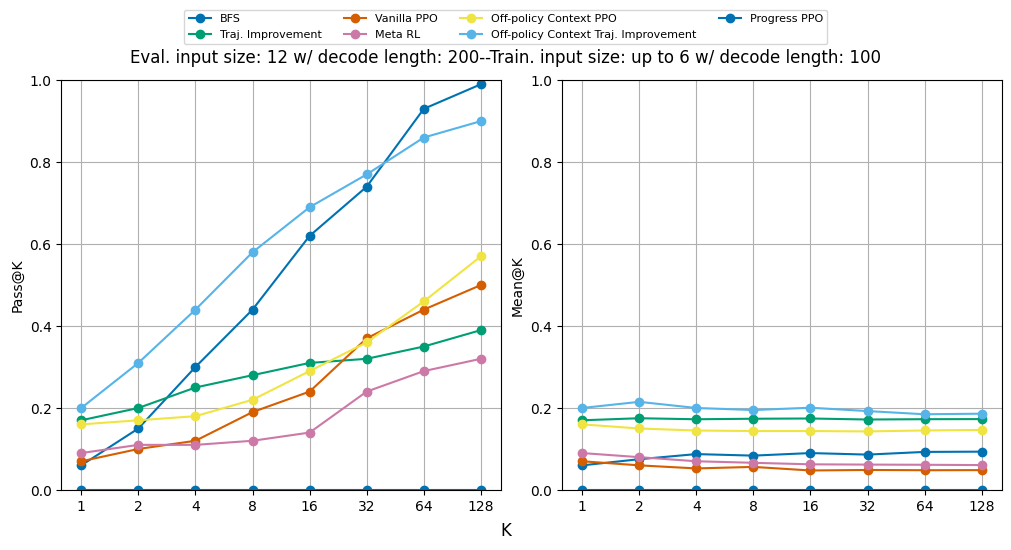

In [9]:
def compute_wilson_ci(n, acc):
    # alpha = 0.05
    base = (n * acc + 0.5 * 3.841) / (n + 3.841)
    err = np.sqrt(3.841) / (n + 3.841) * np.sqrt(n * acc * (1 - acc) + 0.25 * 3.841)

    return (base - err, base + err)

if num_evals > 1:
    x_range = np.arange(math.ceil(np.log2(num_evals)) + 1)
    num_cols = 2
    num_rows = 1
    fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))
    for i, (exp_name, res_array) in enumerate(results.items()):
        success_array = res_array[0].reshape((batch_size, num_evals))
        pass_k = np.mean(np.maximum.accumulate(success_array, axis=-1), axis=0)
        mean_k = np.mean(np.cumsum(success_array, axis=-1) / np.arange(1, num_evals + 1), axis=0)

        scatter = axes[0].plot(
            x_range,
            pass_k[2 ** x_range - 1],
            label=exp_name,
            marker="o",
        )

        scatter = axes[1].plot(
            x_range,
            mean_k[2 ** x_range - 1],
            marker="o",
        )

    axes[0].set_xticks(x_range)
    axes[0].set_xticklabels(2 ** x_range)
    axes[0].set_ylabel("Pass@K")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(True)
    axes[1].set_xticks(x_range)
    axes[1].set_xticklabels(2 ** x_range)
    axes[1].set_ylabel("Mean@K")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(True)
    
    fig.suptitle("Eval. input size: {} w/ decode length: {}--Train. input size: up to {} w/ decode length: {}".format(
        max_bits,
        max_response_length,
        train_num_bits,
        train_max_decode_len,
    ))
    fig.supxlabel("K")
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=4,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )
else:
    num_cols = 1
    num_rows = 1
    fig, ax = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))
    success_rates = []
    exp_names = []
    for i, (exp_name, res_array) in enumerate(results.items()):
        success_array = res_array[0].reshape((batch_size, num_evals))
        success_rates.append(np.mean(success_array))
        exp_names.append(exp_name)

    x_range = np.arange(len(success_rates))
    ax.bar(
        x_range,
        success_rates,
    )
    ax.set_xticks(x_range, exp_names, rotation=30, ha="right")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True)

    fig.suptitle("Eval. input size: {} w/ decode length: {}--Train. input size: up to {} w/ decode length: {}".format(
        max_bits,
        max_response_length,
        train_num_bits,
        train_max_decode_len,
    ))
    fig.supxlabel("Model")
    fig.supylabel("Greedy decoding success rate")
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=4,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )

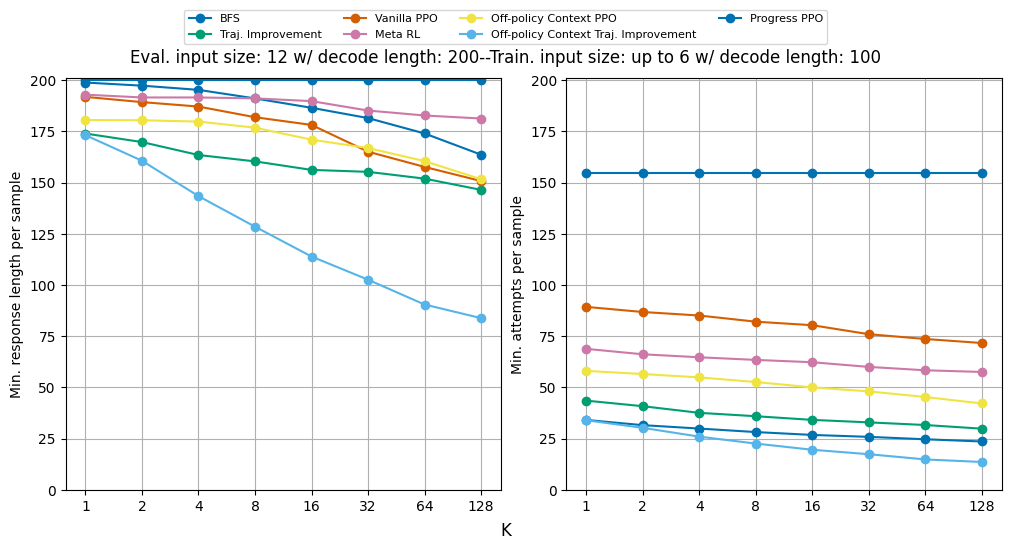

In [10]:
if num_evals > 1:
    x_range = np.arange(math.ceil(np.log2(num_evals)) + 1)
    num_cols = 2
    num_rows = 1
    fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))

    for i, (exp_name, res_array) in enumerate(results.items()):
        success_array = res_array[0].reshape((batch_size, num_evals))
        rlength_array = res_array[1].reshape((batch_size, num_evals))
        reset_array = res_array[2].reshape((batch_size, num_evals))
        rlength_array = rlength_array.at[jnp.logical_not(success_array)].set(max_response_length)
        min_response_length_per_sample = np.minimum.accumulate(rlength_array, axis=-1)
        min_response_length = np.mean(min_response_length_per_sample, axis=0)
        min_attempt_per_sample = np.minimum.accumulate(reset_array, axis=-1)
        min_attempt = np.mean(min_attempt_per_sample, axis=0)
        mean_attempt_per_sample = np.cumsum(reset_array, axis=-1) / np.arange(1, num_evals + 1)
        mean_attempt = np.mean(mean_attempt_per_sample, axis=0)

        scatter = axes[0].plot(
            x_range,
            min_response_length[2 ** x_range - 1],
            label=exp_name,
            marker="o",
        )
        axes[0].set_xticks(x_range)
        axes[0].set_xticklabels(2 ** x_range)
        axes[0].set_ylabel("Min. response length per sample")
        axes[0].set_ylim(0.0, max_response_length + 1)
        axes[0].grid(True)

        scatter = axes[1].plot(
            x_range,
            min_attempt[2 ** x_range - 1],
            marker="o",
        )
        axes[1].set_xticks(x_range)
        axes[1].set_xticklabels(2 ** x_range)
        axes[1].set_ylabel("Min. attempts per sample")
        axes[1].grid(True)
        axes[1].set_ylim(0.0, max_response_length + 1)

    fig.supxlabel("K")
    
    fig.suptitle("Eval. input size: {} w/ decode length: {}--Train. input size: up to {} w/ decode length: {}".format(
        max_bits,
        max_response_length,
        train_num_bits,
        train_max_decode_len,
    ))
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=4,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )
else:
    num_cols = 2
    num_rows = 1
    fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))
    rlengths = []
    resets = []
    exp_names = []
    for i, (exp_name, res_array) in enumerate(results.items()):
        rlength_array = res_array[1].reshape((batch_size, num_evals))
        reset_array = res_array[2].reshape((batch_size, num_evals))
        rlengths.append(np.mean(rlength_array))
        resets.append(np.mean(reset_array))
        exp_names.append(exp_name)

    x_range = np.arange(len(exp_names))
    axes[0].bar(
        x_range,
        rlengths,
    )
    axes[0].set_xticks(x_range, exp_names, rotation=30, ha="right")
    axes[0].set_ylabel("Min. response length per sample")
    axes[0].set_ylim(0.0, max_response_length + 1)
    axes[0].grid(True)

    axes[1].bar(
        x_range,
        resets,
    )
    axes[1].set_xticks(x_range, exp_names, rotation=30, ha="right")
    axes[1].set_ylabel("Min. attempts per sample")
    axes[1].set_ylim(0.0, max_response_length + 1)
    axes[1].grid(True)

    fig.suptitle("Eval. input size: {} w/ decode length: {}--Train. input size: up to {} w/ decode length: {}".format(
        max_bits,
        max_response_length,
        train_num_bits,
        train_max_decode_len,
    ))
    fig.supxlabel("Model")
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=4,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )

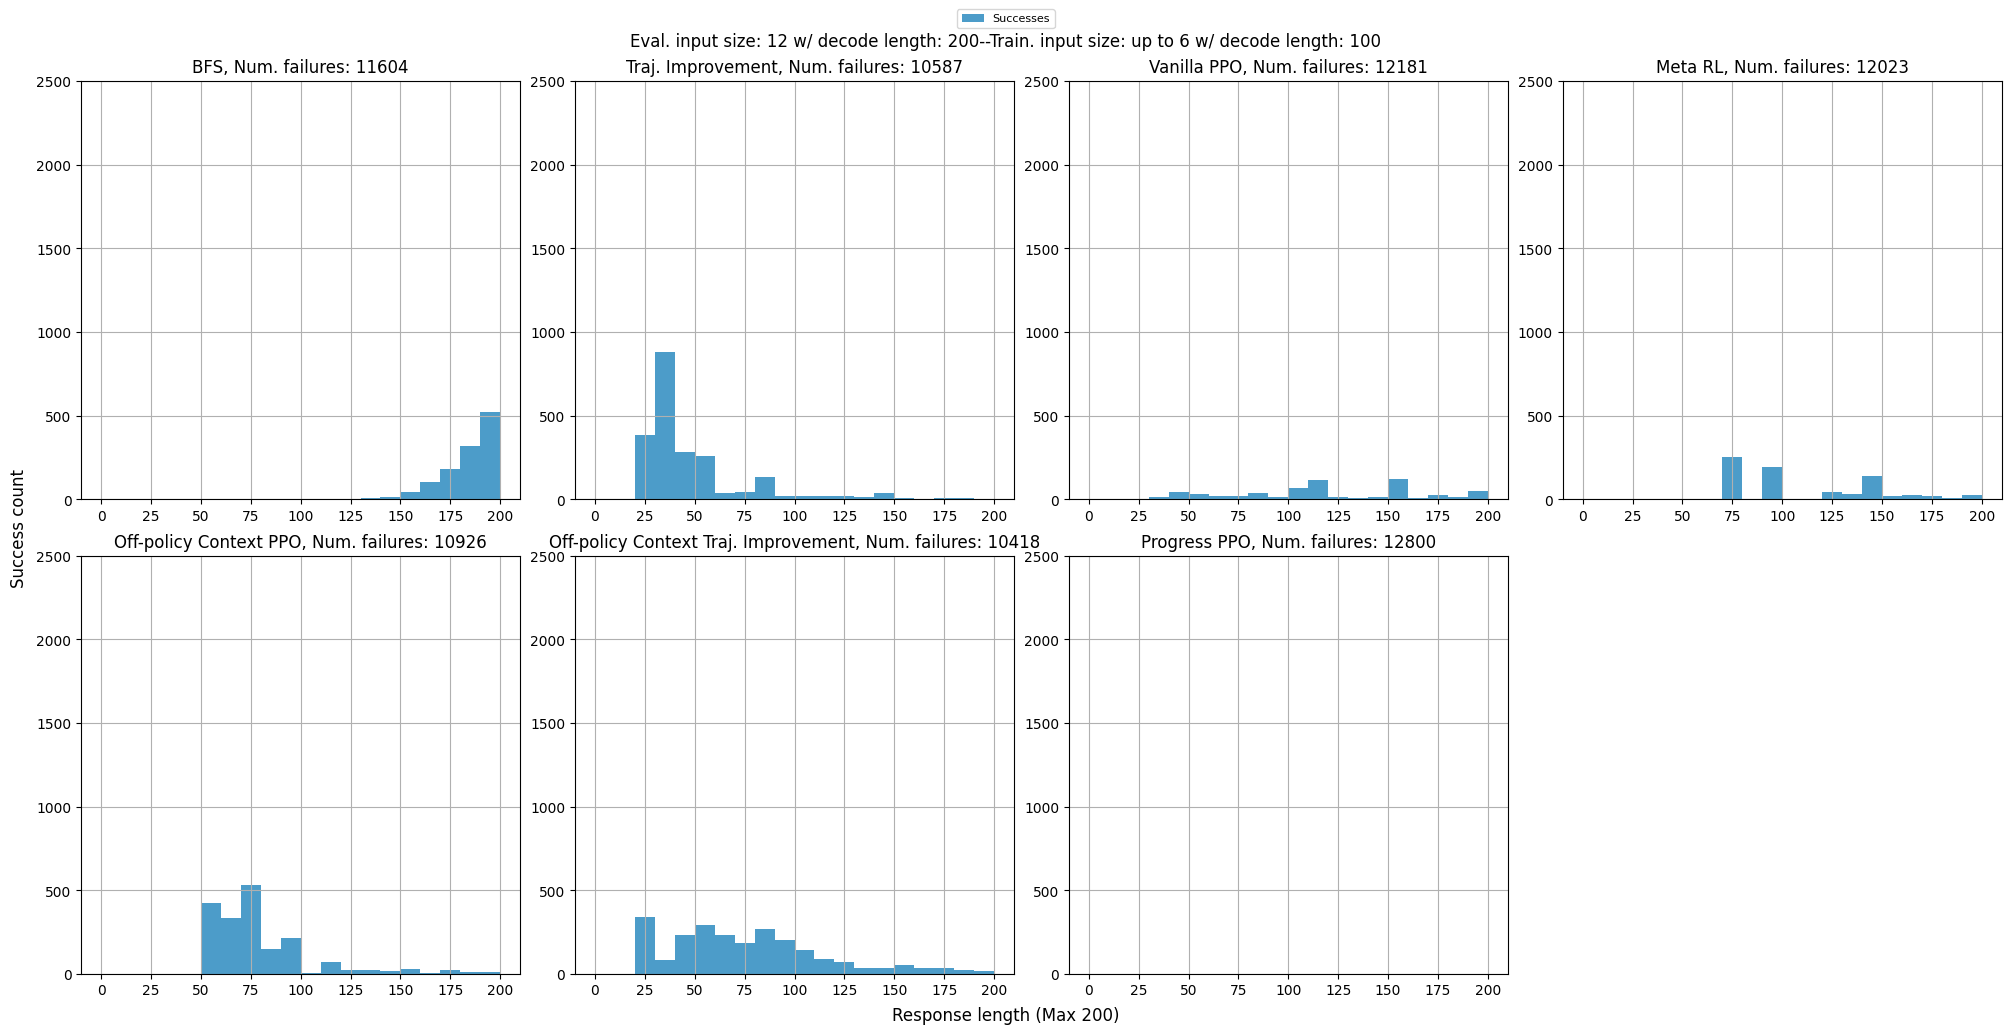

In [11]:
num_cols = 4
num_rows = math.ceil(len(results) / num_cols)
fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))

delta = 10
axes = axes.flatten()
max_success = max([np.sum(res_array[0], axis=-1) for (exp_name, res_array) in results.items() if exp_name != "BFS"])
max_failure = max([np.sum(1 - res_array[0], axis=-1) for (exp_name, res_array) in results.items() if exp_name != "BFS"])
for i, (exp_name, res_array) in enumerate(results.items()):
    success_array = res_array[0]
    rlength_array = res_array[1]
    success_only_rlength = rlength_array[np.where(success_array)]
    failure_only_rlength = np.sum(np.logical_not(success_array))

    counts, bins = np.histogram(success_only_rlength, bins=np.arange(0, max_response_length + delta, delta))
    scatter = axes[i].hist(bins[:-1], bins, weights=counts, color="C0", alpha=0.7, label="Successes" if i == 0 else "")

    axes[i].set_ylim(0, max_success * 1.05)
    axes[i].set_title("{}, Num. failures: {}".format(exp_name, failure_only_rlength))
    axes[i].grid(True)

for i in range(len(results), num_cols * num_rows):
    axes[i].axis("off")

fig.supylabel("Success count")
fig.supxlabel("Response length (Max {})".format(max_response_length))
fig.suptitle("Eval. input size: {} w/ decode length: {}--Train. input size: up to {} w/ decode length: {}".format(
    max_bits,
    max_response_length,
    train_num_bits,
    train_max_decode_len,
))
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=4,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

In [12]:
assert 0

AssertionError: 

In [ ]:
with_question_save_name = "attempt_diversity_results-{}-checkpoint_{}-max_response_length_{}{}.dill".format(
    group_name,
    checkpoint_i * config.logging_config.checkpoint_interval if checkpoint_i >= 0 else "last",
    max_response_length,
    "-deterministic" if num_evals == 1 else "",
)
hide_question_save_name = "attempt_diversity_results-{}-checkpoint_{}-max_response_length_{}-hide_question{}.dill".format(
    group_name,
    checkpoint_i * config.logging_config.checkpoint_interval if checkpoint_i >= 0 else "last",
    max_response_length,
    "-deterministic" if num_evals == 1 else "",
)

with_question_results = dill.load(open(with_question_save_name, "rb"))
hide_question_results = dill.load(open(hide_question_save_name, "rb"))

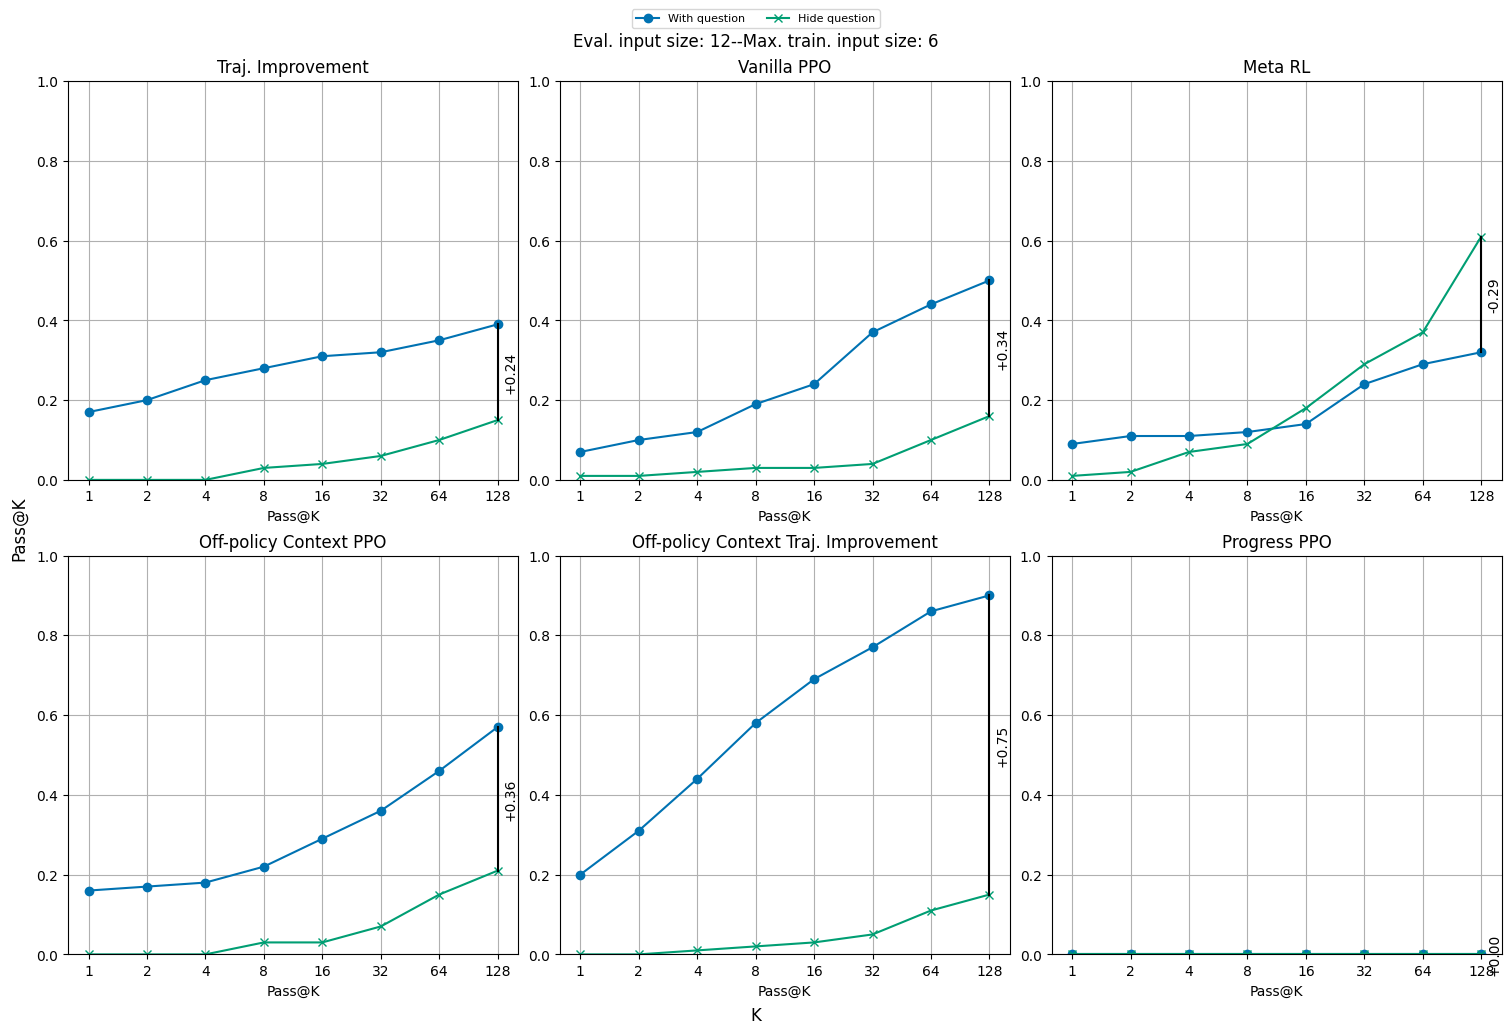

In [ ]:
num_cols = 3
num_rows = math.ceil(len(results) / 3)
fig, axes = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))

delta = 25
axes = axes.flatten()
for i, exp_name in enumerate(run_names):

    with_q_success_array = with_question_results[exp_name][0].reshape((batch_size, num_evals))
    hide_q_success_array = hide_question_results[exp_name][0].reshape((batch_size, num_evals))
    with_q_pass_k = np.mean(np.maximum.accumulate(with_q_success_array, axis=-1), axis=0)
    hide_q_pass_k = np.mean(np.maximum.accumulate(hide_q_success_array, axis=-1), axis=0)

    scatter = axes[i].plot(
        x_range,
        with_q_pass_k[2 ** x_range - 1],
        label="With question" if i == 0 else "",
        marker="o",
    )

    scatter = axes[i].plot(
        x_range,
        hide_q_pass_k[2 ** x_range - 1],
        label="Hide question" if i == 0 else "",
        marker="x",
    )

    improvement = (with_q_pass_k[2 ** x_range - 1] - hide_q_pass_k[2 ** x_range - 1])
    max_y = max(with_q_pass_k[2 ** x_range - 1][-1], hide_q_pass_k[2 ** x_range - 1][-1])
    min_y = min(with_q_pass_k[2 ** x_range - 1][-1], hide_q_pass_k[2 ** x_range - 1][-1])
    axes[i].axvline(x_range[-1], ymin=min_y, ymax=max_y, c="black")
    axes[i].text(
        x_range[-1] + 0.1,
        (max_y + min_y) / 2,
        "{}{:.2f}".format("+" if improvement[-1] >= 0 else "-", np.abs(improvement[-1])),
        rotation=90,
        verticalalignment="center",
    )

    axes[i].set_title(exp_name)
    axes[i].set_xticks(x_range)
    axes[i].set_xticklabels(2 ** x_range)
    axes[i].set_xlabel("Pass@K")
    axes[i].set_ylim(0.0, 1.0)
    axes[i].grid(True)

fig.supylabel("Pass@K")
fig.supxlabel("K")
fig.suptitle("Eval. input size: {}--Max. train. input size: {}".format(max_bits, train_num_bits))
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=3,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

TODO:
Perhaps there's some entropy tradeoff here... Double check OPC traj. improve. ablation.

In [ ]:
assert 0

In [ ]:
run_names.keys()

In [ ]:
results = dict()

exp_name = "Off-policy Context Traj. Improvement"
# exp_name = "Traj. Improvement"
run_name = run_names[exp_name]
learner_path = os.path.join(base_path, algo_name, run_name)
config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))

checkpoint_results = {}
for checkpoint in tqdm(sorted(os.listdir(os.path.join(learner_path, "models")))):
    # Load model
    train_state = dill.load(
        open(os.path.join(learner_path, "models", checkpoint), "rb")
    )

    model = nnx.merge(
        train_state.graphdef,
        train_state.params,
        train_state.rest,
    )

    rng = jax.random.PRNGKey(eval_seed)
    rng, rollout_rng = jax.random.split(rng)

    # Sample next batch and evaluate
    _, init_cache = make_autoregressive(
        model,
        max_decode_len=max_decode_len,
        batch_size=batch_size * num_evals,
        embed_dim=config_dict["model_config"]["model_kwargs"]["embed_dim"],
        dtype=dtype,
        eval_mode=True,
    )
    cache = init_cache()
    graphdef, _, rest = nnx.split(model, nnx.Cache, ...)

    rollout_res = rollout(
        graphdef,
        cache,
        rest,
        rollout_rng,
        batch,
        eos_token=dataset.eos_token_id,
        deterministic=0,
        correct_aware_shift=dataset.correctness_aware_tokens_offset,
        max_token_id_to_shift=dataset.max_token_id_to_shift,
    )

    num_resets = np.sum((rollout_res.observations * rollout_res.pred_mask) == dataset.reset_token_id, axis=-1)
    checkpoint_results[int(checkpoint.split(".")[0])] = jnp.vstack((
        rollout_res.success,
        rollout_res.response_length,
        num_resets,
    ), dtype=int)

In [ ]:
skip_step = 2
checkpoints = None
checkpoint_interval = config_dict["logging_config"]["checkpoint_interval"]
last_checkpoint = max(list(checkpoint_results.keys()))

if checkpoints is None:
    checkpoints = []
    for checkpoint_i in checkpoint_results:
        if (
            checkpoint_i != last_checkpoint
            and checkpoint_i > 0
            and checkpoint_i % (skip_step * checkpoint_interval) != 0
        ):
            continue
        checkpoints.append(checkpoint_i)

print(checkpoints)

x_range = np.arange(math.ceil(np.log2(num_evals)) + 1)
num_cols = 1
num_rows = 1
fig, ax = plt.subplots(num_rows, num_cols, layout="constrained", figsize=(5.0 * num_cols, 5.0 * num_rows))

for plot_i, checkpoint_i in enumerate(checkpoints):
    res_array = checkpoint_results[checkpoint_i]
    success_array = res_array[0].reshape((batch_size, num_evals))
    pass_k = np.mean(np.maximum.accumulate(success_array, axis=-1), axis=0)
        
    scatter = ax.plot(
        x_range,
        pass_k[2 ** x_range - 1],
        label=checkpoint_i,
        marker="o",
    )
    ax.set_xticks(x_range)
    ax.set_xticklabels(2 ** x_range)
    ax.set_ylim(0.0, 1.0)
    ax.grid(True)

fig.supylabel("Success rate")
fig.supxlabel("Pass@K")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

In [ ]:
assert 0

In [ ]:
reset_mask = (rollout_res.observations * rollout_res.pred_mask) == dataset.reset_token_id

In [ ]:
all_trials = []
for sample_i, (
    observations,
    pred_mask,
    response_length,
    question_len,
) in enumerate(zip(
    rollout_res.observations,
    rollout_res.pred_mask,
    rollout_res.response_length,
    batch["question_len"],
)):
    pred_traj = observations * pred_mask
    pred_traj = pred_traj.at[question_len + response_length].set(dataset.reset_token_id)
    reset_idxes = np.where(pred_traj == dataset.reset_token_id)[0]
    per_sample_trials = dict()
    first_ooc_trial = -1
    for trial_i, (start_idx, end_idx) in enumerate(zip(reset_idxes[:-1], reset_idxes[1:])):
        curr_trial = "".join(map(str, pred_traj[start_idx:end_idx]))
        per_sample_trials.setdefault(curr_trial, [])
        per_sample_trials[curr_trial].append(trial_i)
        if end_idx <= train_max_decode_len:
            first_ooc_trial = trial_i + 1

    all_trials.append((len(reset_idxes) - 1, first_ooc_trial, per_sample_trials))

In [ ]:
jnp.mean(jnp.max(rollout_res.success.reshape((batch_size, num_evals))[:, :16], axis=-1))

In [ ]:
jnp.mean(jnp.max(rollout_res.success.reshape((batch_size, num_evals)), axis=-1))

## TODO:
- Success rate at OOD context length (not the question length, but context usage)
- Is the decoding biased towards 1? If there's a lot of 1s in the solution then success rate is high?
- A new MDP where we only provide the best responsea and failed action so far as the context?

In [ ]:
top_k = 5
max_sample = 10

for sample_i, curr_trial in enumerate(all_trials):
    if sample_i == max_sample:
        break
    # if rollout_res.success[sample_i]:
    #     continue

    num_trials, first_ooc_trial, trial_idxes = curr_trial
    x_range = np.arange(1, num_trials + 1)
    trial_density = {
        k: np.sum(np.array(v)[None] < x_range[:, None], axis=-1) #/ (x_range + 1)
        for k, v in trial_idxes.items()
    }

    fig, ax = plt.subplots(1, 1, layout="constrained", figsize=(6, 6))

    ax.axvline(
        first_ooc_trial + 1, # index off by 1
        c="gray",
        label="First OOD context-len attempt",
        alpha=0.5,
    )

    longest_response_idx = np.argmax([len(v) for v in trial_density.keys()])
    top_k_response_idxes = np.argsort([v[-1] for v in trial_density.values()])[-top_k:]
    for response_i, (k, v) in enumerate(trial_density.items()):
        if (
            response_i not in top_k_response_idxes
            and
            response_i != longest_response_idx
        ):
            continue

        ax.plot(
            (x_range + 1)[:50],
            v[:50],
            label=k,
            linestyle="--" if response_i == longest_response_idx else "-"
        )

    print("Sample: {}, Success: {}, Required attempts: {}".format(
        sample_i,
        rollout_res.success[sample_i],
        num_trials,
    ))
    fig.suptitle(
        "Unique attempt density for sample {}\nQuestion: {}\nSolution: {}\n% of 1s in sol'n: {}".format(
            sample_i,
            batch["sequence"][sample_i][:np.where(batch["sequence"][sample_i] == dataset.eos_token_id)[0][0]],
            batch["target"][sample_i][:np.where(batch["target"][sample_i] == dataset.eos_token_id)[0][0]],
            np.sum(batch["target"][sample_i] == 1) / batch["solution_len"][sample_i]
        )
    )
    ax.set_ylabel("Mass")
    ax.set_xlabel("$j$'th Attempt")
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=6,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )
    plt.show()